In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import altair as alt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, export_text
import shap
import scipy

/Users/darwin/Projects/datathon/heart-disease-classificaiton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the processed Cleveland dataset
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", 
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

df = pd.read_csv("../heart+disease/processed.cleveland.data", names=columns, na_values="?")

# Will remove missing values as we have a lot of data
df = df.dropna()

# In the original data, target 0 = no disease, 1-4 = disease severity
# For binary classification, we will map 1-4 to 1
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

df.head()

Dataset loaded: 297 rows, 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
# Create mapping of variables 
vis_df = df.copy()
vis_df['Diagnosis'] = vis_df['target'].map({0: 'No Disease', 1: 'Disease'})
vis_df['Chest Pain Type'] = vis_df['cp'].map({
    1: 'Typical Angina', 
    2: 'Atypical Angina', 
    3: 'Non-anginal', 
    4: 'Asymptomatic'
})

# Color scale 
color_scale = alt.Scale(domain=['No Disease', 'Disease'], range=['#2e8b57', '#cd5c5c'])

# Start of EDA (baseline)

# Bar chart for Chest Pain Type
chart_cp = alt.Chart(vis_df).mark_bar().encode(
    x=alt.X('Chest Pain Type:N', title='Chest Pain Type', sort='-y'),
    y=alt.Y('count():Q', title='Patient Count'),
    color=alt.Color('Diagnosis:N', scale=color_scale),
    tooltip=['Chest Pain Type', 'Diagnosis', 'count()']
).properties(title='Baseline: Chest Pain Type', width=350, height=250)

# Density plot for Age
chart_age = alt.Chart(vis_df).transform_density(
    'age',
    as_=['age', 'density'],
    groupby=['Diagnosis']
).mark_area(opacity=0.6).encode(
    x=alt.X('age:Q', title='Age (Years)'),
    y=alt.Y('density:Q', title='Density'),
    color=alt.Color('Diagnosis:N', scale=color_scale),
    tooltip=['Diagnosis']
).properties(title='Baseline: Age Distribution', width=350, height=250)


# Stress test features 

# Density plot for Max Heart Rate (thalach)
chart_thalach = alt.Chart(vis_df).transform_density(
    'thalach',
    as_=['thalach', 'density'],
    groupby=['Diagnosis']
).mark_area(opacity=0.6).encode(
    x=alt.X('thalach:Q', title='Maximum Heart Rate (thalach)'),
    y=alt.Y('density:Q', title='Density'),
    color=alt.Color('Diagnosis:N', scale=color_scale)
).properties(title='Stress Test: Max Heart Rate', width=350, height=250)

# Boxplot for ST Depression (oldpeak)
chart_oldpeak = alt.Chart(vis_df).mark_boxplot(extent='min-max').encode(
    x=alt.X('Diagnosis:N', title='Diagnosis'),
    y=alt.Y('oldpeak:Q', title='ST Depression (oldpeak)'),
    color=alt.Color('Diagnosis:N', scale=color_scale)
).properties(title='Stress Test: ST Depression', width=350, height=250)

# Dashboard visaulization 
dashboard = (chart_cp | chart_age) & (chart_thalach | chart_oldpeak)

dashboard = dashboard.resolve_scale(
    color='independent'
).configure_title(
    fontSize=16,
    anchor='start'
).configure_axis(
    labelFontSize=12,
    titleFontSize=14
)

dashboard

alt.VConcatChart(...)

In [4]:
# Define mapping tiers towards our models 
tiers = {
    "Tier 1: Baseline": ["age", "sex", "cp"],
    "Tier 2: Vitals": ["age", "sex", "cp", "trestbps", "fbs"],
    "Tier 3: Blood Lab": ["age", "sex", "cp", "trestbps", "fbs", "chol"],
    "Tier 4: Stress Test": ["age", "sex", "cp", "trestbps", "fbs", "chol", 
                            "restecg", "thalach", "exang", "oldpeak", "slope"],
    "Tier 5: Specialized": ["age", "sex", "cp", "trestbps", "fbs", "chol", 
                             "restecg", "thalach", "exang", "oldpeak", "slope", 
                             "ca", "thal"]
}

In [5]:
# Creating 75/25 test train splits 
X = df.drop('target', axis=1)
y = df['target']

# Want to stratify to keep the proportion of sick/healthy patients 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=100, stratify=y) 

# Creating bootstrap distribution (non-parametric) to fit on larger scale data
# Create statistical significance of 95% 
def calculate_auc_ci(y_true, y_pred, n_bootstraps=5000):
    rng = np.random.RandomState(100)
    bootstrapped_scores = []
    
    # Ensure y_true is a numpy array for correct indexing
    y_true_arr = np.array(y_true)
    
    for i in range(n_bootstraps):
        indices = rng.randint(0, len(y_pred), len(y_pred))
        
        if len(np.unique(y_true_arr[indices])) < 2:
            # Skip if all samples in bootstrap are the same class
            continue
        
        score = auc(*roc_curve(y_true_arr[indices], y_pred[indices])[:2])
        bootstrapped_scores.append(score)
        
    sorted_scores = np.array(bootstrapped_scores)
    sorted_scores.sort()
    ci_lower = sorted_scores[int(0.025 * len(sorted_scores))]
    ci_upper = sorted_scores[int(0.975 * len(sorted_scores))]
    return ci_lower, ci_upper

# Training model and storing metrics 
results = []
roc_data = []

for name, feature_list in tiers.items():
    # Using a random forest classifier 
    clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=100)
    clf.fit(X_train[feature_list], y_train)
    
    # Get predictions
    probs = clf.predict_proba(X_test[feature_list])[:, 1]
    
    # Calculate ROC and AUC
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    ci_lower, ci_upper = calculate_auc_ci(y_test, probs)
    
    # Store Stats
    results.append({
        "Tier": name, 
        "AUC": round(roc_auc, 3), 
        "95% CI Lower": round(ci_lower, 3), 
        "95% CI Upper": round(ci_upper, 3)
    })
    
    # Store Plotting Data
    temp_df = pd.DataFrame({'False Positive Rate': fpr, 'True Positive Rate': tpr, 'Tier': [name] * len(fpr)})
    roc_data.append(temp_df)

# Output Statistical Numbers
performance_df = pd.DataFrame(results)
print(performance_df.to_markdown(index=False))
performance_df.to_csv("triage_auc_results.csv", index=False)

# ROC visaul
all_roc_df = pd.concat(roc_data)

line = alt.Chart(all_roc_df).mark_line().encode(
    x=alt.X('False Positive Rate:Q'),
    y=alt.Y('True Positive Rate:Q'),
    color=alt.Color('Tier:N', sort=list(tiers.keys())),
    tooltip=['Tier', 'False Positive Rate', 'True Positive Rate']
).properties(title='Triage Performance: ROC Curve Comparison', width=600, height=450)

# The diagonal random-chance line (AUC = 0.5)
guide = alt.Chart(pd.DataFrame({'x': [0, 1], 'y': [0, 1]})).mark_line(strokeDash=[5,5], color='gray').encode(x='x', y='y')

# Render Dashboard
dashboard = (line + guide)
dashboard

| Tier                |   AUC |   95% CI Lower |   95% CI Upper |
|:--------------------|------:|---------------:|---------------:|
| Tier 1: Baseline    | 0.799 |          0.692 |          0.891 |
| Tier 2: Vitals      | 0.78  |          0.67  |          0.878 |
| Tier 3: Blood Lab   | 0.81  |          0.703 |          0.902 |
| Tier 4: Stress Test | 0.858 |          0.766 |          0.936 |
| Tier 5: Specialized | 0.889 |          0.81  |          0.955 |


alt.LayerChart(...)

In [6]:
# DeLong test 
def compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1)
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T + 1
    
    return T2

def fastDeLong(predictions_sorted_transposed, label_1_count):
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m
    positive_examples = predictions_sorted_transposed[:, :m]
    negative_examples = predictions_sorted_transposed[:, m:]
    tx = np.empty([positive_examples.shape[0], m], dtype=float)
    ty = np.empty([negative_examples.shape[0], n], dtype=float)
    tz = np.empty([predictions_sorted_transposed.shape[0], m + n], dtype=float)
    for r in range(predictions_sorted_transposed.shape[0]):
        tx[r, :] = compute_midrank(positive_examples[r, :])
        ty[r, :] = compute_midrank(negative_examples[r, :])
        tz[r, :] = compute_midrank(predictions_sorted_transposed[r, :])
    aucs = tz[:, :m].sum(axis=1) / m / n - float(m + 1.0) / 2.0 / n
    v01 = (tz[:, :m] - tx[:, :]) / n
    v10 = 1.0 - (tz[:, m:] - ty[:, :]) / m
    sx = np.cov(v01)
    sy = np.cov(v10)
    delongcov = sx / m + sy / n
    return aucs, delongcov

def calc_pvalue(aucs, sigma):
    l = np.array([[1, -1]])
    z = np.abs(np.diff(aucs)) / np.sqrt(np.dot(np.dot(l, sigma), l.T))
    return 10 ** (scipy.stats.norm.logsf(z) / np.log(10)) * 2

def delong_roc_test(y_true, y_pred1, y_pred2):
    # Ensure inputs are numpy arrays
    y_true = np.asarray(y_true)
    y_pred1 = np.asarray(y_pred1)
    y_pred2 = np.asarray(y_pred2)
    
    # Sort predictions so that the positive class labels come first
    order = np.argsort(y_true)[::-1]
    y_true_sorted = y_true[order]
    
    predictions_sorted_transposed = np.vstack((y_pred1[order], y_pred2[order]))
    label_1_count = np.sum(y_true_sorted)
    
    aucs, delongcov = fastDeLong(predictions_sorted_transposed, label_1_count)
    p_value = calc_pvalue(aucs, delongcov)
    return p_value[0][0]

In [7]:
# Initialize the dictionary to store probabilities
model_probs = {}

# Re-run the training loop to capture 'probs' for DeLong
for name, feature_list in tiers.items():
    # Using a fixed random_state for reproducibility
    clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
    clf.fit(X_train[feature_list], y_train)
    
    # Capture the probability of the positive class (target=1)
    # We use X_test to ensure we are testing on unseen data
    probs = clf.predict_proba(X_test[feature_list])[:, 1]
    
    # Store in our dictionary
    model_probs[name] = probs

In [8]:
print(f"{'Tier Comparison':<25} | {'p-value':<10} | {'Significance'}")
print("-" * 55)

# Reference point for comparison
baseline_key = "Tier 1: Baseline"
baseline_probs = model_probs[baseline_key]

# Explicitly print the Baseline as the reference point
print(f"{baseline_key:<25} | {'N/A':<10} | Reference Model")

# Loop through the remaining tiers to compare them against the baseline
for tier_name in tiers.keys():
    if tier_name == baseline_key:
        continue
        
    current_tier_probs = model_probs[tier_name]
    
    # Call the DeLong function defined earlier
    p_val = delong_roc_test(y_test, baseline_probs, current_tier_probs)
    
    # 0.05 threshold 
    significance = "Significant" if p_val < 0.05 else "Not Significant"
    
    print(f"{tier_name:<25} | {p_val:.4f}     | {significance}")

Tier Comparison           | p-value    | Significance
-------------------------------------------------------
Tier 1: Baseline          | N/A        | Reference Model
Tier 2: Vitals            | 0.6653     | Not Significant
Tier 3: Blood Lab         | 0.7493     | Not Significant
Tier 4: Stress Test       | 0.0958     | Not Significant
Tier 5: Specialized       | 0.0650     | Not Significant


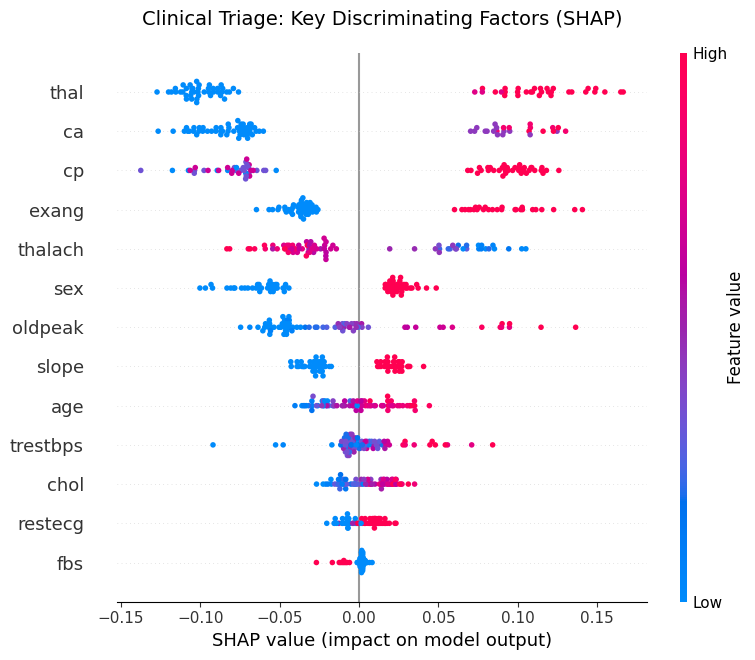

In [9]:
# Explicitly isolate the features for our 'Full Clinical' model (Tier 5)
full_features = tiers["Tier 5: Specialized"]
X_train_full = X_train[full_features]
X_test_full = X_test[full_features]

# Train the model
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train_full, y_train)

# Model predictions using SHAP
explainer = shap.TreeExplainer(model)
shap_vals = explainer.shap_values(X_test_full)

# Safely extract the SHAP values for Class 1 (Target = 1 / Disease)
if isinstance(shap_vals, list):
    # Older SHAP versions return a list
    shap_for_class_1 = shap_vals[1]
elif len(shap_vals.shape) == 3:
    # Newer SHAP versions return a 3D numpy array: (samples, features, classes)
    shap_for_class_1 = shap_vals[:, :, 1]
else:
    # Create fallback if cases do not work 
    shap_for_class_1 = shap_vals

plt.figure(figsize=(10, 6))
plt.title("Clinical Triage: Key Discriminating Factors (SHAP)", fontsize=14, pad=20)
shap.summary_plot(shap_for_class_1, X_test_full, show=False)
plt.tight_layout()
plt.show()

Estimated:

Tier,AUC (Actual),Est. Cost ($),Est. Time (Min),ROI (AUC / $100)
1. Baseline,0.799,$20,10,3.99 (High)
2. Vitals,0.780,$40,15,1.95 (Low)
3. Blood Lab,0.810,$150,120,0.54 (Low)
4. Stress Test,0.858,$500,60,0.17 (Med)
5. Specialized,0.889,"$2,500",180,0.03 (Low)

In [10]:
# Define the "Fast-Track" Features (Intentionally skipping Tiers 2 & 3)
# We exclude blood pressure, fasting blood sugar, and cholesterol to save time/money
fast_track_tiers = {
    "Step 1: Intake": ["age", "sex", "cp"],
    "Step 2: Stress Test": ["age", "sex", "cp", "restecg", "thalach", "exang", "oldpeak", "slope"],
    "Step 3: Imaging": ["age", "sex", "cp", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal"]
}

# Costs and Times based on our health economics matrix (estimated)
resource_costs = {
    "Step 1: Intake": {"cost": 20, "time": 10},
    "Step 2: Stress Test": {"cost": 500, "time": 60},
    "Step 3: Imaging": {"cost": 2500, "time": 180}
}

# Cascading models 
models = {}

for name, features in fast_track_tiers.items():
    clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=100)
    clf.fit(X_train[features], y_train)
    models[name] = clf

# Sequential Triage Logic
def cascading_triage(X_patient, models, fast_track_tiers):
    # Thresholds for confidence: "Safe Zones"
    # If probability is < 20% (Healthy) or > 80% (Sick), we trust the model and stop
    # Explained with LR
    t1_lower, t1_upper = 0.20, 0.80 
    # Create tighter thresholds for second run 
    t2_lower, t2_upper = 0.35, 0.65 
    
    # Create the baseline 
    p1 = models["Step 1: Intake"].predict_proba(X_patient[fast_track_tiers["Step 1: Intake"]])[:, 1][0]
    if p1 <= t1_lower or p1 >= t1_upper:
        return {"prediction": round(p1), "final_step": "Step 1: Intake", "cost": 20, "time": 10}
        
    # Stress Test (For the "Uncertain" cases)
    p2 = models["Step 2: Stress Test"].predict_proba(X_patient[fast_track_tiers["Step 2: Stress Test"]])[:, 1][0]
    if p2 <= t2_lower or p2 >= t2_upper:
        return {"prediction": round(p2), "final_step": "Step 2: Stress Test", "cost": 20+500, "time": 10+60}
        
    # Specialized Imaging (For the most complex cases)
    p3 = models["Step 3: Imaging"].predict_proba(X_patient[fast_track_tiers["Step 3: Imaging"]])[:, 1][0]
    return {"prediction": round(p3), "final_step": "Step 3: Imaging", "cost": 20+500+2500, "time": 10+60+180}

# Evaluation on test 
results = []

for i in range(len(X_test)):
    patient_data = X_test.iloc[[i]]
    result = cascading_triage(patient_data, models, fast_track_tiers)
    result['actual'] = y_test.iloc[i]
    results.append(result)

results_df = pd.DataFrame(results)

# Calculate the ROI and accuracy 
total_cost_cascade = results_df['cost'].sum()
total_time_cascade = results_df['time'].sum()
accuracy = accuracy_score(results_df['actual'], results_df['prediction'])

# Consider against baseline 
# Assuming typical workflow 
cost_standard = len(X_test) * (20 + 40 + 150 + 500 + 2500)
time_standard = len(X_test) * (10 + 15 + 120 + 60 + 180)

print(f"Cascading Model Accuracy: {accuracy:.3f}")
print("-" * 30)
print("Patient Distribution:")
print(results_df['final_step'].value_counts())
print("-" * 30)
print(f"Total Cost (Cascade): ${total_cost_cascade:,.2f}")
print(f"Total Cost (Standard): ${cost_standard:,.2f}")
print(f"Total Savings: ${cost_standard - total_cost_cascade:,.2f}")

Cascading Model Accuracy: 0.773
------------------------------
Patient Distribution:
final_step
Step 1: Intake         35
Step 2: Stress Test    29
Step 3: Imaging        11
Name: count, dtype: int64
------------------------------
Total Cost (Cascade): $49,000.00
Total Cost (Standard): $240,750.00
Total Savings: $191,750.00


Clinical Triage Flowchart (Extracted Rules):

|--- thal <= 4.50
|   |--- ca <= 0.50
|   |   |--- thalach <= 160.50
|   |   |   |--- class: 0
|   |   |--- thalach >  160.50
|   |   |   |--- class: 0
|   |--- ca >  0.50
|   |   |--- cp <= 3.50
|   |   |   |--- class: 0
|   |   |--- cp >  3.50
|   |   |   |--- class: 1
|--- thal >  4.50
|   |--- ca <= 0.50
|   |   |--- thalach <= 144.50
|   |   |   |--- class: 1
|   |   |--- thalach >  144.50
|   |   |   |--- class: 0
|   |--- ca >  0.50
|   |   |--- trestbps <= 109.00
|   |   |   |--- class: 0
|   |   |--- trestbps >  109.00
|   |   |   |--- class: 1



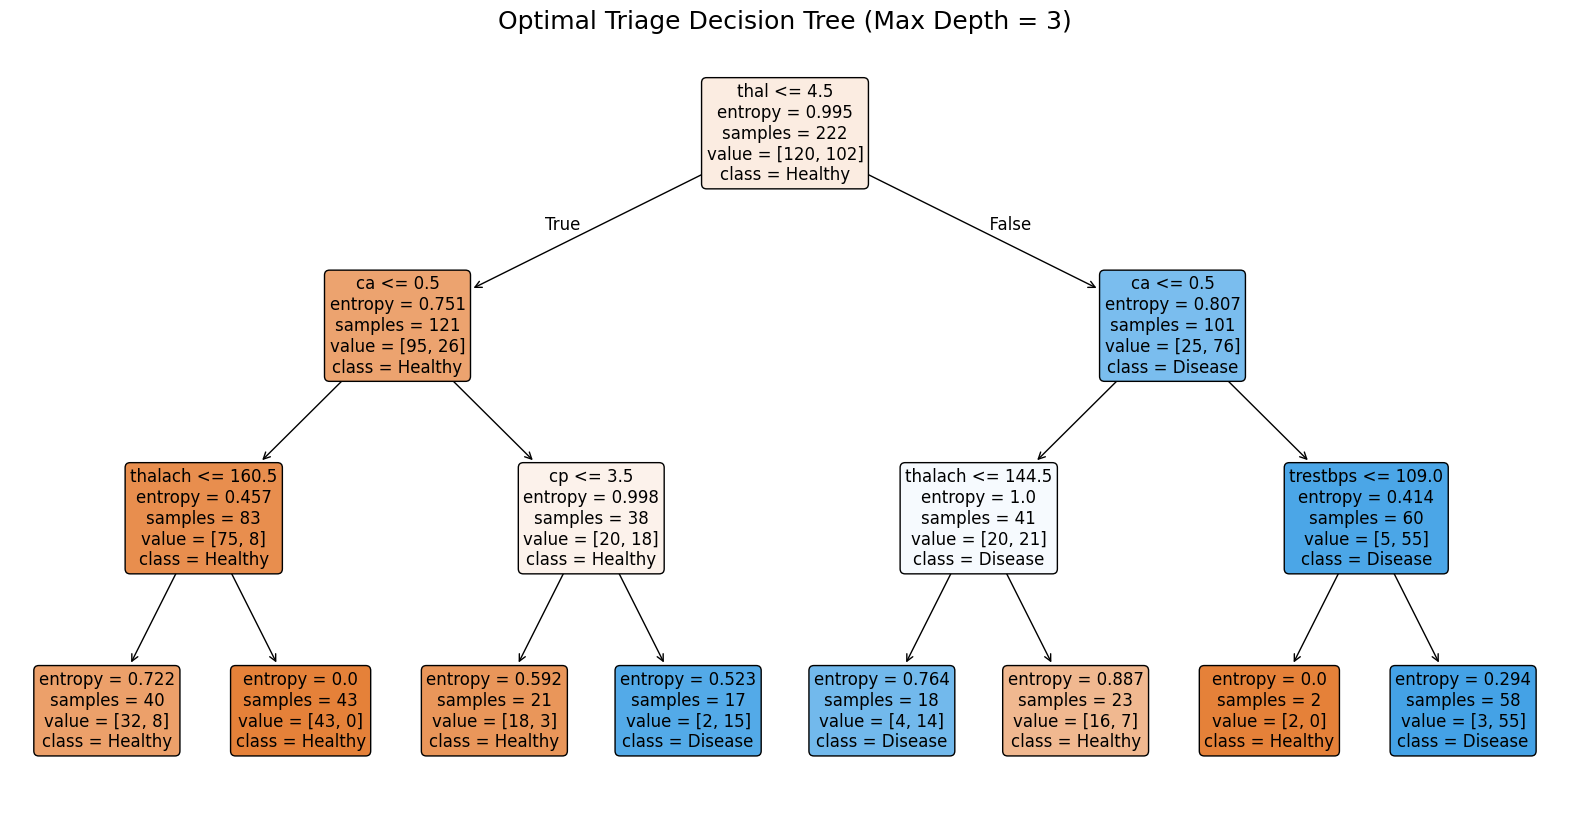

In [ ]:
# Train shallow decision tree, max_depth=3 
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42, criterion='entropy')

# Train on the FULL feature set (Tier 5) to see which variables it picks
full_features = tiers["Tier 5: Specialized"]
dt_model.fit(X_train[full_features], y_train)

# Extract the literal text rules (The "Optimal Path")
tree_rules = export_text(dt_model, feature_names=full_features)
print("Clinical Triage Flowchart (Extracted Rules):\n")
print(tree_rules)

# Visualizing the Tree
plt.figure(figsize=(20,10))
tree.plot_tree(dt_model, 
               feature_names=full_features,  
               class_names=["Healthy", "Disease"],
               filled=True, 
               rounded=True, 
               fontsize=12)
plt.title("Optimal Triage Decision Tree (Max Depth = 3)", fontsize=18)
plt.show()